# BrushCue Example: Kaleidoscope

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/kaleidoscope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/kaleidoscope

In [ ]:
!pip install brushcue

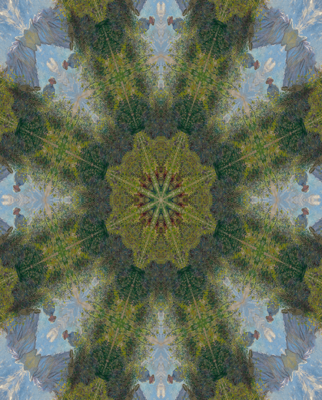

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("  // Get normalized coordinates (0.0 to 1.0)\n  let dims_u = textureDimensions(input_texture);\n  let dims = vec2<f32>(dims_u);\n\n  // Pixel-center UV (reduces half-texel bias vs vec2(position)/dims)\n  let uv = (vec2<f32>(position) + vec2<f32>(0.5)) / dims;\n\n  // Center to [-0.5, 0.5] space\n  var p = uv - vec2<f32>(0.5);\n\n  p = rotate2(p, rotation);\n\n  // Polar\n  let angle_raw = atan2(p.y, p.x);\n  var r = length(p);\n\n  // Optional: subtle radial warp to feel more \"glass-like\"\n  // (set warp=0.0 to disable)\n  r = r + warp * sin(r * warp_frequency);\n\n  // Kaleidoscope fold (clean wedge mirror)\n  let TAU = 6.28318530718;\n  let seg = TAU / segments;\n\n  // Map angle into [0, seg), then mirror fold into [0, seg/2]\n  var a = fract((angle_raw + TAU) / seg) * seg;\n  a = abs(a - 0.5 * seg);\n\n  // Radius scale (controls zoom/coverage)\n  let r2 = r * 1.5;\n\n  // Back to UV\n  var k = vec2<f32>(cos(a), sin(a)) * r2 + vec2<f32>(0.5);\n\n  // Prefer mirror wrap to avoid \"stuck-to-edge\" clamp rings\n  k = vec2<f32>(mirror01(k.x), mirror01(k.y));\n\n  return sample(input_texture, k);")
string_constant_3 = brushcue.string_constant("// Helper function for safe texture sampling (nearest-neighbor)\nfn sample_at(texture: texture_2d<f32>, uv: vec2<f32>) -> vec4<f32> {\n  let dims = textureDimensions(texture);\n  let clamped = clamp(uv, vec2<f32>(0.0), vec2<f32>(0.9999));\n  let pos = vec2<u32>(clamped * vec2<f32>(dims));\n  return textureLoad(texture, pos, 0);\n}\n\n// Mirror-wrap a scalar into [0, 1] with reflected repeats.\n// This tends to look more \"kaleidoscope-like\" than clamping.\nfn mirror01(x: f32) -> f32 {\n  let t = fract(x);\n  return 1.0 - abs(2.0 * t - 1.0);\n}\n\n// 2D rotation around origin\nfn rotate2(v: vec2<f32>, radians: f32) -> vec2<f32> {\n  let c = cos(radians);\n  let s = sin(radians);\n  return vec2<f32>(c * v.x - s * v.y, s * v.x + c * v.y);\n}")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
string_constant_6 = brushcue.string_constant("warp_frequency")
float_constant_7 = brushcue.float_constant(5.0)
string_constant_8 = brushcue.string_constant("warp")
float_constant_9 = brushcue.float_constant(0.0)
string_constant_10 = brushcue.string_constant("rotation")
dictionary_create_11 = brushcue.dictionary_create()
string_constant_12 = brushcue.string_constant("segments")
float_constant_13 = brushcue.float_constant(0.0)
int_constant_14 = brushcue.int_constant(8)
rotation_15 = brushcue.float_passthrough(float_constant_13)
segments_16 = brushcue.int_passthrough(int_constant_14)
int_to_float_17 = brushcue.int_to_float(segments_16)
float_add_to_dictionary_18 = brushcue.float_add_to_dictionary(dictionary_create_11, string_constant_12, int_to_float_17)
float_add_to_dictionary_19 = brushcue.float_add_to_dictionary(float_add_to_dictionary_18, string_constant_10, rotation_15)
float_add_to_dictionary_20 = brushcue.float_add_to_dictionary(float_add_to_dictionary_19, string_constant_8, float_constant_9)
float_add_to_dictionary_21 = brushcue.float_add_to_dictionary(float_add_to_dictionary_20, string_constant_6, float_constant_7)
kaleidoscope_shader_22 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_4, float_add_to_dictionary_21, bool_constant_5)

ctx = brushcue.Context()
result = kaleidoscope_shader_22.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
